## 4.3 Reduced Feature Neural Network Model

This notebook builds the reduced neural network model using features selected by the tuned decision tree from Task 2. The ROC evaluation in this file is only for the reduced neural network model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc


### Data preparation for reduced neural network

The same Task 1 preprocessing is repeated here so this notebook can run independently. Categorical variables are one-hot encoded, continuous numeric variables are standardised, and binary dummy variables are kept as 0/1 values.


In [2]:
df = pd.read_csv('../Asm1_dataset26.csv')
df.columns = df.columns.str.strip()
df = df.drop_duplicates(keep='first')

min_temp_cols = ['Min temp_D1_D30', 'Min temp_D31_D60', 'Min temp_D61_D90', 'Min temp_D91_D120']
for col in min_temp_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].replace('--', 'NA')

df['yield_per_hec'] = df['Paddy yield(in Kg)'] / df['Hectares']
mean_yield = df['yield_per_hec'].mean()
df['isAboveAvg'] = np.where(df['yield_per_hec'] > mean_yield, 1, 0)

drop_cols = ['Hectares', 'Paddy yield(in Kg)', 'yield_per_hec', 'Trash(in bundles)']
df_clean = df.drop(columns=drop_cols)

df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
X = df_encoded.drop(columns=['isAboveAvg'])
y = df_encoded['isAboveAvg']

corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.98)]
X_final = X.drop(columns=high_corr_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

binary_cols = [col for col in X_train.columns if X_train[col].nunique() == 2]
continuous_cols = [col for col in X_train.columns if col not in binary_cols]

scaler = StandardScaler()
X_train_nn = X_train.copy()
X_test_nn = X_test.copy()

X_train_nn[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_nn[continuous_cols] = scaler.transform(X_test[continuous_cols])

X_train_nn = X_train_nn.astype(float)
X_test_nn = X_test_nn.astype(float)

print(f'Full feature matrix before reduction: {X_final.shape}')
print(f'Train size before reduction: {X_train_nn.shape}')
print(f'Test size before reduction: {X_test_nn.shape}')


Full feature matrix before reduction: (2628, 50)
Train size before reduction: (1971, 50)
Test size before reduction: (657, 50)


### Feature selection using tuned decision tree

The reduced feature set is selected using the best decision tree settings from Task 2. Features with non-zero importance are retained for the reduced neural network.


In [3]:
feature_selector_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_leaf=5,
    min_samples_split=20,
    random_state=42
)

feature_selector_tree.fit(X_train, y_train)

tree_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_selector_tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

important_features_nn = tree_importance.loc[tree_importance['Importance'] > 0, 'Feature'].tolist()

print(f'Number of selected features: {len(important_features_nn)}')
for idx, feature in enumerate(important_features_nn, start=1):
    print(idx, feature)

tree_importance.head(15)


Number of selected features: 13
1 Seedrate(in Kg)
2 Variety_delux ponni
3 Variety_ponmani
4 Relative Humidity_D31_D60
5 Max temp_D61_D90
6 Wind Direction_D61_D90_NNW
7 Wind Direction_D31_D60_NE
8 51_70DRain(in mm)
9 Wind Direction_D1_D30_NA
10 Wind Direction_D61_D90_SW
11 Nursery_wet
12 Soil Types_clay
13 Wind Direction_D31_D60_W


,Feature,Importance
0,Seedrate(in Kg),0.946465
24,Variety_delux ponni,0.030967
25,Variety_ponmani,0.007056
16,Relative Humidity_D31_D60,0.004621
8,Max temp_D61_D90,0.004553
41,Wind Direction_D61_D90_NNW,0.001934
35,Wind Direction_D31_D60_NE,0.001361
3,51_70DRain(in mm),0.000987
29,Wind Direction_D1_D30_NA,0.000847
43,Wind Direction_D61_D90_SW,0.000466


In [4]:
important_features_nn

['Seedrate(in Kg)',
 'Variety_delux ponni',
 'Variety_ponmani',
 'Relative Humidity_D31_D60',
 'Max temp_D61_D90',
 'Wind Direction_D61_D90_NNW',
 'Wind Direction_D31_D60_NE',
 '51_70DRain(in mm)',
 'Wind Direction_D1_D30_NA',
 'Wind Direction_D61_D90_SW',
 'Nursery_wet',
 'Soil Types_clay',
 'Wind Direction_D31_D60_W']

### GridSearchCV for reduced neural network

The reduced model uses only the selected important features. A smaller architecture search is used because the model has fewer input variables.


In [ ]:
X_train_reduced_nn = X_train_nn[important_features_nn]
X_test_reduced_nn = X_test_nn[important_features_nn]

nn_reduced = MLPClassifier(
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=20,
    random_state=42
)

param_grid_nn_reduced = {
    'hidden_layer_sizes': [(10,), (25,), (25, 10),(100,), (100, 50), (50, 25, 10)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1],
    'learning_rate_init': [0.001, 0.01]
}

grid_search_nn_reduced = GridSearchCV(
    estimator=nn_reduced,
    param_grid=param_grid_nn_reduced,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_nn_reduced.fit(X_train_reduced_nn, y_train)

best_nn_reduced = grid_search_nn_reduced.best_estimator_
y_train_pred_nn_reduced = best_nn_reduced.predict(X_train_reduced_nn)
y_test_pred_nn_reduced = best_nn_reduced.predict(X_test_reduced_nn)

train_acc_nn_reduced = accuracy_score(y_train, y_train_pred_nn_reduced)
test_acc_nn_reduced = accuracy_score(y_test, y_test_pred_nn_reduced)
accuracy_gap_nn_reduced = train_acc_nn_reduced - test_acc_nn_reduced
converged_nn_reduced = best_nn_reduced.n_iter_ < best_nn_reduced.max_iter

print('Best reduced neural network parameters:')
print(grid_search_nn_reduced.best_params_)
print(f'Best cross-validation accuracy: {grid_search_nn_reduced.best_score_:.4f}')
print(f'Train accuracy: {train_acc_nn_reduced:.4f}')
print(f'Test accuracy: {test_acc_nn_reduced:.4f}')
print(f'Train-test accuracy gap: {accuracy_gap_nn_reduced:.4f}')
print(f'Iterations used by best model: {best_nn_reduced.n_iter_}')
print(f'Did the training stop before max_iter? {converged_nn_reduced}')
print(f'Final loss: {best_nn_reduced.loss_:.4f}')


Best reduced neural network parameters:
{'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (25, 10), 'learning_rate_init': 0.01}
Best cross-validation accuracy: 0.8955
Train accuracy: 0.9011
Test accuracy: 0.8889
Train-test accuracy gap: 0.0122
Iterations used by best model: 36
Did the training stop before max_iter? True
Final loss: 0.2202


In [6]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred_nn_reduced))

              precision    recall  f1-score   support

           0       0.96      0.81      0.88       332
           1       0.84      0.97      0.90       325

    accuracy                           0.89       657
   macro avg       0.90      0.89      0.89       657
weighted avg       0.90      0.89      0.89       657



In [7]:
nn_reduced_cv_results = pd.DataFrame(grid_search_nn_reduced.cv_results_).sort_values('rank_test_score')
nn_reduced_cv_results[[
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'param_hidden_layer_sizes',
    'param_activation',
    'param_alpha',
    'param_learning_rate_init'
]].head(10)


,rank_test_score,mean_test_score,std_test_score,param_hidden_layer_sizes,param_activation,param_alpha,param_learning_rate_init
17,1,0.895488,0.018026,"(25, 10)",relu,0.0100,0.01
11,2,0.894983,0.022334,"(25, 10)",relu,0.0010,0.01
1,3,0.891424,0.020336,"(10,)",relu,0.0001,0.01
13,4,0.890917,0.020344,"(10,)",relu,0.0100,0.01
7,5,0.890409,0.020465,"(10,)",relu,0.0010,0.01
29,6,0.888894,0.019423,"(25, 10)",tanh,0.0010,0.01
23,6,0.888894,0.019423,"(25, 10)",tanh,0.0001,0.01
35,8,0.888386,0.019365,"(25, 10)",tanh,0.0100,0.01
5,9,0.888384,0.022460,"(25, 10)",relu,0.0001,0.01
9,10,0.887881,0.019408,"(25,)",relu,0.0010,0.01


### ROC evaluation for reduced neural network

This ROC curve evaluates only the reduced neural network model. The final combined comparison will be written later.


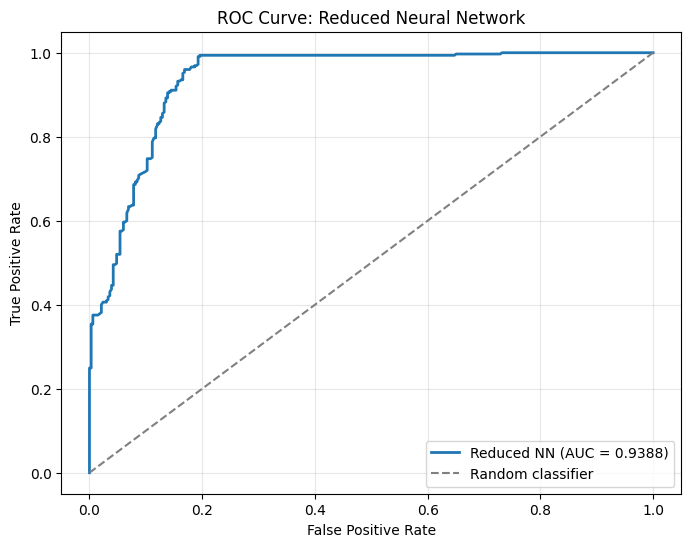

Reduced neural network AUC: 0.9388


In [8]:
y_prob_nn_reduced = best_nn_reduced.predict_proba(X_test_reduced_nn)[:, 1]
fpr_nn_reduced, tpr_nn_reduced, _ = roc_curve(y_test, y_prob_nn_reduced)
auc_nn_reduced = auc(fpr_nn_reduced, tpr_nn_reduced)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nn_reduced, tpr_nn_reduced, label=f'Reduced NN (AUC = {auc_nn_reduced:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Reduced Neural Network')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f'Reduced neural network AUC: {auc_nn_reduced:.4f}')
